# Hierarchical Models

Partial pooling across groups — the "8 schools" style model. Group-level means share a common
prior whose parameters are themselves inferred from data.

**Model:**
$$\mu_{\text{global}} \sim \text{Normal}(0, 10)$$
$$\sigma_{\text{group}} \sim \text{HalfNormal}(5)$$
$$\mu_j \sim \text{Normal}(\mu_{\text{global}},\ \sigma_{\text{group}})$$
$$y_{ij} \sim \text{Normal}(\mu_j,\ \sigma_{\text{obs}})$$

In [1]:
import numpy as np
import rustmc as rmc
import arviz as az
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

## Simulate Data

In [2]:
np.random.seed(42)
J = 8
sigma_obs = 2.0
N_per_group = 30
mu_true = np.array([5.0, -1.0, 3.0, 0.0, 8.0, 2.0, -3.0, 6.0])

ys   = [np.random.normal(mu_true[j], sigma_obs, N_per_group) for j in range(J)]
data = {f"y_{j}": ys[j] for j in range(J)}

print(f"True mu_global:   {mu_true.mean():.2f}")
print(f"True sigma_group: {mu_true.std():.2f}")
print(f"True mu_j:        {mu_true.tolist()}")

True mu_global:   2.50
True sigma_group: 3.50
True mu_j:        [5.0, -1.0, 3.0, 0.0, 8.0, 2.0, -3.0, 6.0]


## Build the Model

Hyperpriors are declared first. `mu_global` and `sigma_group` are `ParamRef` objects —
rustmc resolves them to graph nodes at sample time so gradients flow up to the hyperpriors.

In [3]:
builder = rmc.ModelBuilder(data=data)

mu_global   = builder.normal_prior("mu_global",   mu=0.0, sigma=10.0)
sigma_group = builder.half_normal_prior("sigma_group", sigma=5.0)

mu_j = [
    builder.normal_prior(f"mu_{j}", mu=mu_global, sigma=sigma_group)
    for j in range(J)
]

for j in range(J):
    builder.normal_likelihood(f"obs_{j}", mu_expr=mu_j[j], sigma=sigma_obs, observed_key=f"y_{j}")

model = builder.build()

## Sample

In [4]:
fit = rmc.sample(model_spec=model, chains=4, draws=2000, warmup=1000, seed=42)
print(fit.summary())

Sampling done: 12000/12000 | 128 div | elapsed 1s


4 chains × 2000 draws per chain

Parameter        mean      std     hdi_3%    hdi_97%   ess_bulk   ess_tail    r_hat  mcse_mean
────────────────────────────────────────────────────────────────────────────────────────────────
mu_global      2.4020   1.2983     0.0555     4.7618        122        342   1.0280   0.117312
sigma_group    4.1013   1.1551     2.5297     6.7398       7998       7998   1.0019   0.012917
mu_0           4.6099   0.3622     3.9189     5.2830       7998       7998   1.0000   0.004049
mu_1          -1.2178   0.3632    -1.8997    -0.5282       7998       7998   1.0002   0.004061
mu_2           3.0163   0.3606     2.3360     3.6990       7998       7998   0.9999   0.004032
mu_3          -0.0135   0.3666    -0.6839     0.6875       7998       7998   1.0000   0.004099
mu_4           7.7568   0.3665     7.0757     8.4591       7998       7998   0.9998   0.004098
mu_5           2.5568   0.3709     1.8681     3.2589       7998       7998   1.0000   0.004147
mu_6          -

## ArviZ Diagnostics

In [5]:
idata = fit.to_arviz()
az.summary(idata, round_to=4)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,2.4020,1.2983,0.3098,4.9163,0.1384,0.0484,88.5945,294.2703,1.0276
sigma_group,4.1013,1.1551,2.3172,6.2237,0.0180,0.0189,4021.6192,5947.9044,1.0021
mu_0,4.6099,0.3622,3.9105,5.2697,0.0036,0.0042,10249.4393,6273.0873,1.0001
mu_1,-1.2178,0.3632,-1.9104,-0.5462,0.0039,0.0040,8530.2035,6106.1516,1.0002
mu_2,3.0163,0.3606,2.3400,3.7017,0.0036,0.0042,9987.3182,6307.4503,1.0008
mu_3,-0.0135,0.3666,-0.7159,0.6450,0.0041,0.0042,7944.7545,5688.9539,1.0000
mu_4,7.7568,0.3665,7.0633,8.4353,0.0033,0.0043,12036.6233,6245.7885,1.0005
mu_5,2.5568,0.3709,1.8646,3.2525,0.0037,0.0042,10201.7864,6408.1608,1.0006
mu_6,-2.8198,0.3690,-3.5220,-2.1290,0.0037,0.0042,9985.6812,5919.5705,1.0005
mu_7,6.0607,0.3590,5.3872,6.7224,0.0035,0.0041,10310.6316,6201.2390,1.0007


## Trace Plot

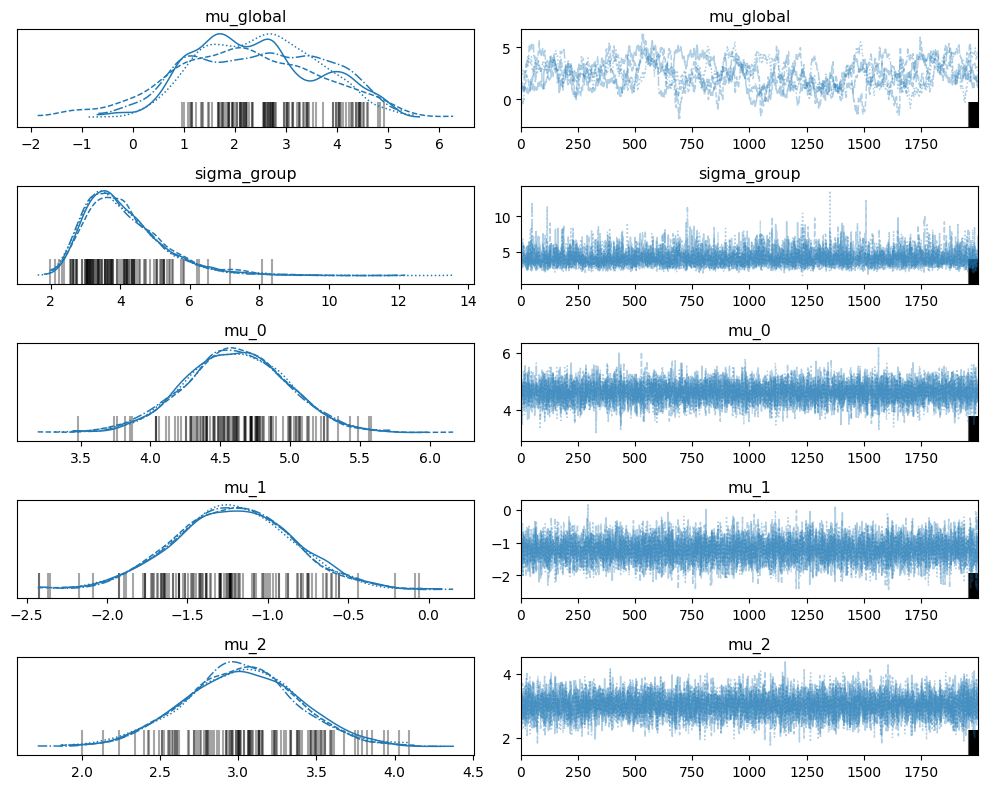

In [6]:
# Show hyperparameters and a few group means
var_names = ["mu_global", "sigma_group", "mu_0", "mu_1", "mu_2"]
az.plot_trace(idata, var_names=var_names, figsize=(10, 8))
plt.tight_layout()
plt.show()

## Forest Plot — Partial Pooling

Shows all group means with HDI. The partial pooling effect (shrinkage toward the global mean)
is visible when comparing the pooled estimates to raw group sample means.

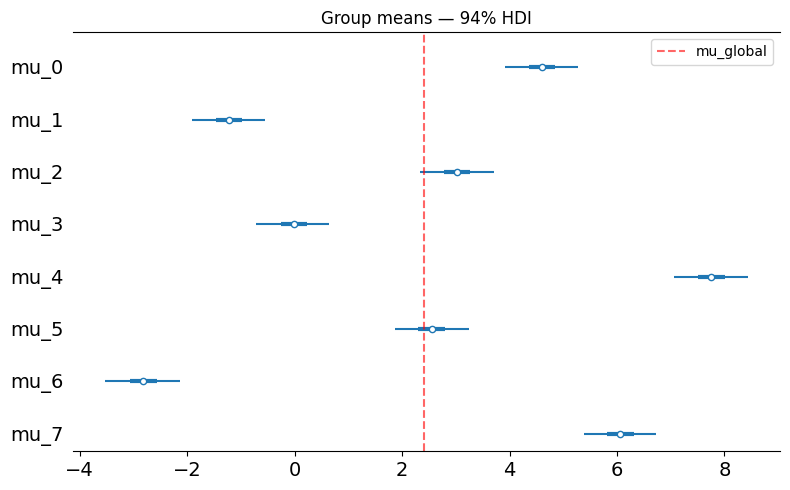

In [7]:
group_vars = [f"mu_{j}" for j in range(J)]
az.plot_forest(idata, var_names=group_vars, combined=True, figsize=(8, 5))
plt.title("Group means — 94% HDI")
plt.axvline(fit.mean()["mu_global"], color="red", linestyle="--", alpha=0.6, label="mu_global")
plt.legend()
plt.tight_layout()
plt.show()

## Partial Pooling Effect

In [8]:
means = fit.mean()
sample_means = [ys[j].mean() for j in range(J)]

print(f"Global mean estimate: {means['mu_global']:.2f}")
print(f"{'Group':<8} {'Raw':>8} {'Pooled':>10} {'True':>8}")
print("-" * 38)
for j in range(J):
    print(f"mu_{j}     {sample_means[j]:+8.2f} {means[f'mu_{j}']:+10.4f} {mu_true[j]:+8.2f}")

Global mean estimate: 2.40
Group         Raw     Pooled     True
--------------------------------------
mu_0        +4.62    +4.6099    +5.00
mu_1        -1.24    -1.2178    -1.00
mu_2        +3.03    +3.0163    +3.00
mu_3        -0.04    -0.0135    +0.00
mu_4        +7.81    +7.7568    +8.00
mu_5        +2.56    +2.5568    +2.00
mu_6        -2.87    -2.8198    -3.00
mu_7        +6.10    +6.0607    +6.00


## Hyperparameter Posterior

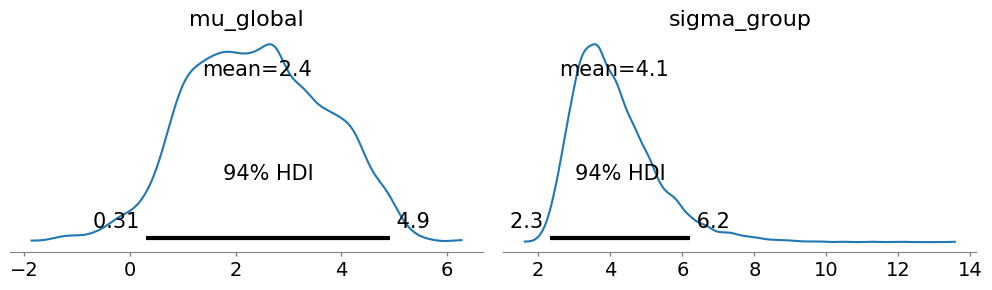

mu_global:   true=2.50  estimated=2.4020 ± 1.2983
sigma_group: true=3.50  estimated=4.1013 ± 1.1551


In [9]:
az.plot_posterior(idata, var_names=["mu_global", "sigma_group"], figsize=(10, 3))
plt.tight_layout()
plt.show()

print(f"mu_global:   true={mu_true.mean():.2f}  estimated={means['mu_global']:.4f} ± {fit.std()['mu_global']:.4f}")
print(f"sigma_group: true={mu_true.std():.2f}  estimated={means['sigma_group']:.4f} ± {fit.std()['sigma_group']:.4f}")